In [1]:
# Cell 1 — Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# File paths
DATA_PATH = "data/processed/"

nav_df         = pd.read_csv(DATA_PATH + "nav_history_clean.csv")
aum_df         = pd.read_csv(DATA_PATH + "aum_by_fund_house_clean.csv")
sip_df         = pd.read_csv(DATA_PATH + "monthly_sip_inflows_clean.csv")
category_df    = pd.read_csv(DATA_PATH + "category_inflows_clean.csv")
transactions_df= pd.read_csv(DATA_PATH + "investor_transactions_clean.csv")
fund_master_df = pd.read_csv(DATA_PATH + "fund_master_clean.csv")
folio_df       = pd.read_csv(DATA_PATH + "industry_folio_count_clean.csv")
performance_df = pd.read_csv(DATA_PATH + "scheme_performance_clean.csv")
holdings_df    = pd.read_csv(DATA_PATH + "portfolio_holdings_clean.csv")
benchmark_df   = pd.read_csv(DATA_PATH + "benchmark_indices_clean.csv")

print("✅ All datasets loaded successfully!")
print(f"NAV records: {len(nav_df):,}")
print(f"Transactions: {len(transactions_df):,}")
print(f"SIP months: {len(sip_df)}")


✅ All datasets loaded successfully!
NAV records: 46,000
Transactions: 32,778
SIP months: 48


In [2]:
print(nav_df.columns.tolist())
print(nav_df.head(2))

['amfi_code', 'date', 'nav']
   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971


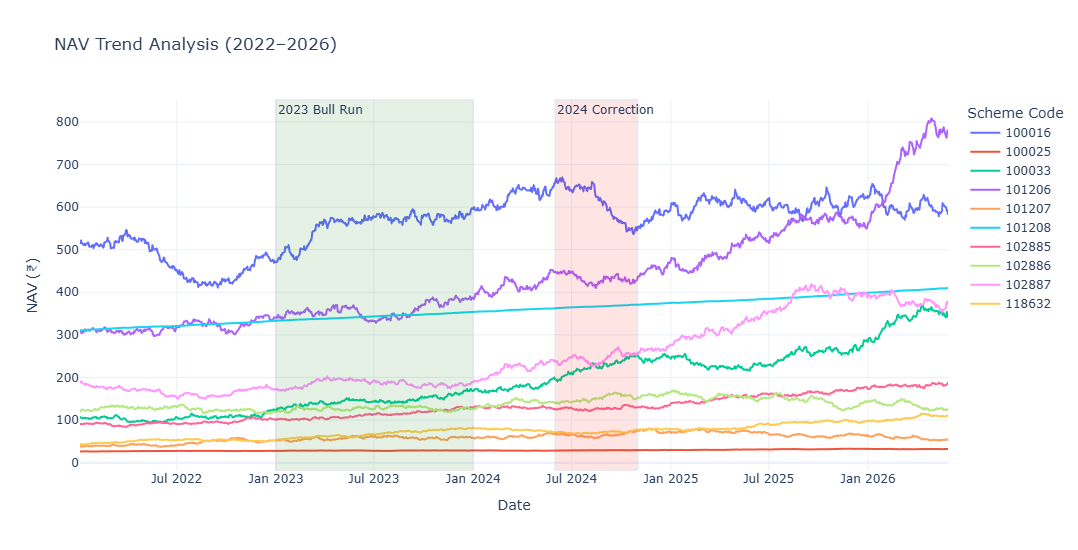

✅ NAV trend chart saved!


In [3]:
# Cell 2 — NAV Trend Analysis (All Schemes 2022–2026)
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

# Get top 10 schemes for clarity
top_schemes = nav_df['amfi_code'].unique()[:10]
nav_filtered = nav_df[nav_df['amfi_code'].isin(top_schemes)]

fig = px.line(
    nav_filtered,
    x='date',
    y='nav',
    color='amfi_code',
    title='NAV Trend Analysis (2022–2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date', 'amfi_code': 'Scheme Code'}
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Highlight 2024 correction
fig.add_vrect(
    x0="2024-06-01", x1="2024-10-31",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction", annotation_position="top left"
)

fig.update_layout(height=550, template='plotly_white')
fig.show()

# Export
import os
os.makedirs("charts", exist_ok=True)
fig.write_image("charts/nav_trend.png")
print("✅ NAV trend chart saved!")

In [4]:
print(aum_df.columns.tolist())
print(aum_df.head(2))

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216


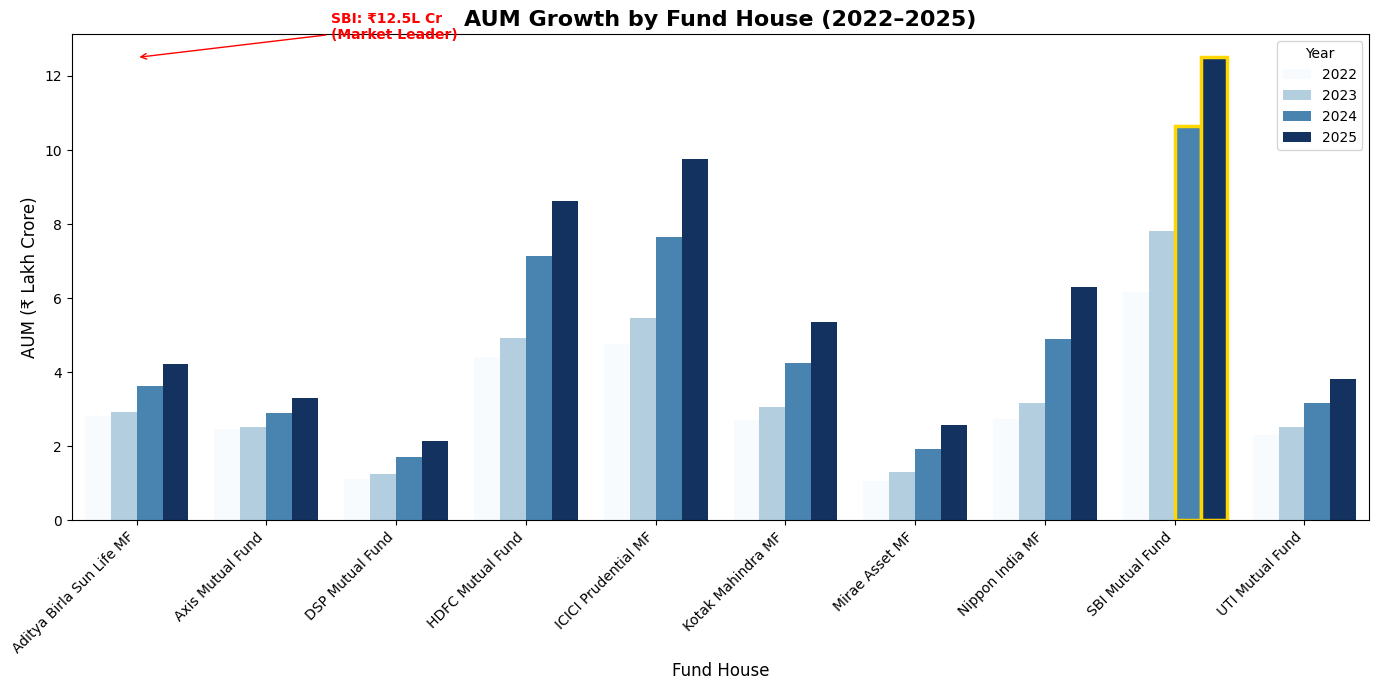

✅ AUM growth chart saved!


In [5]:
# Cell 3 — AUM Growth Bar Chart by Fund House
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

# Aggregate by fund house and year
aum_yearly = aum_df.groupby(['year', 'fund_house'])['aum_lakh_crore'].mean().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_lakh_crore',
    hue='year',
    palette='Blues'
)

# Highlight SBI bars
for bar in ax.patches:
    if bar.get_height() > 10:
        bar.set_edgecolor('gold')
        bar.set_linewidth(2.5)

plt.title('AUM Growth by Fund House (2022–2025)', fontsize=16, fontweight='bold')
plt.xlabel('Fund House', fontsize=12)
plt.ylabel('AUM (₹ Lakh Crore)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()

# Annotate SBI dominance
plt.annotate('SBI: ₹12.5L Cr\n(Market Leader)',
             xy=(0, 12.5), xytext=(1.5, 13),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red', fontweight='bold')

plt.savefig('charts/aum_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ AUM growth chart saved!")

In [6]:
print(sip_df.columns.tolist())
print(sip_df.head(2))

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  


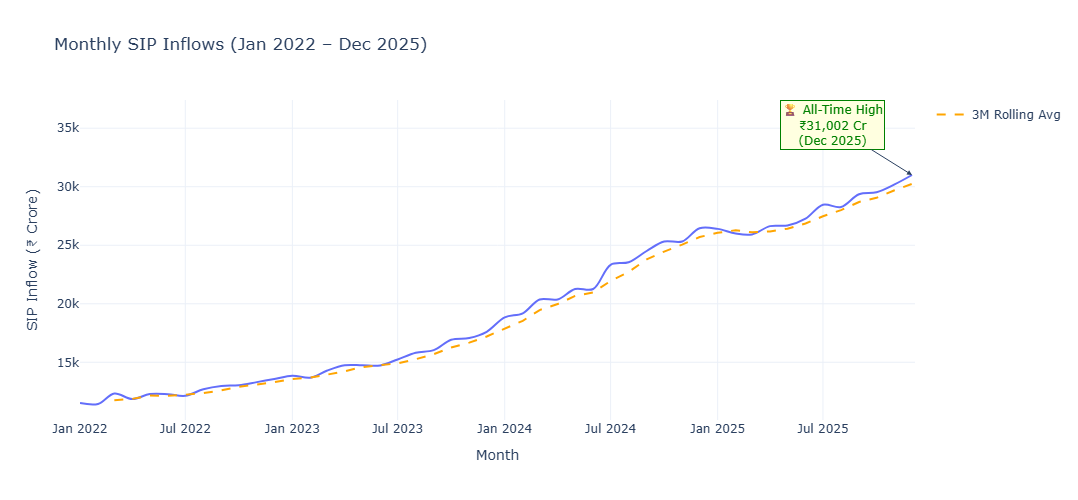

✅ SIP inflow chart saved!


In [8]:
# Cell 4 — SIP Inflow Time Series (Jan 2022 – Dec 2025)
sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(
    sip_df,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    line_shape='spline'
)

# Annotate all-time high
max_row = sip_df.loc[sip_df['sip_inflow_crore'].idxmax()]
fig.add_annotation(
    x=str(max_row['month']),  # fix: convert Timestamp to string
    y=max_row['sip_inflow_crore'],
    text=f"🏆 All-Time High<br>₹{max_row['sip_inflow_crore']:,.0f} Cr<br>(Dec 2025)",
    showarrow=True,
    arrowhead=2,
    ax=-80, ay=-50,
    font=dict(color='green', size=12),
    bgcolor='lightyellow',
    bordercolor='green'
)

# Add 3M rolling average
fig.add_trace(go.Scatter(
    x=sip_df['month'].astype(str),  # fix: convert to string
    y=sip_df['sip_inflow_crore'].rolling(3).mean(),
    mode='lines',
    name='3M Rolling Avg',
    line=dict(color='orange', dash='dash')
))

fig.update_layout(height=500, template='plotly_white')
fig.show()

fig.write_image("charts/sip_inflow.png")
print("✅ SIP inflow chart saved!")

In [9]:
print(category_df.columns.tolist())
print(category_df.head(2))

['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0


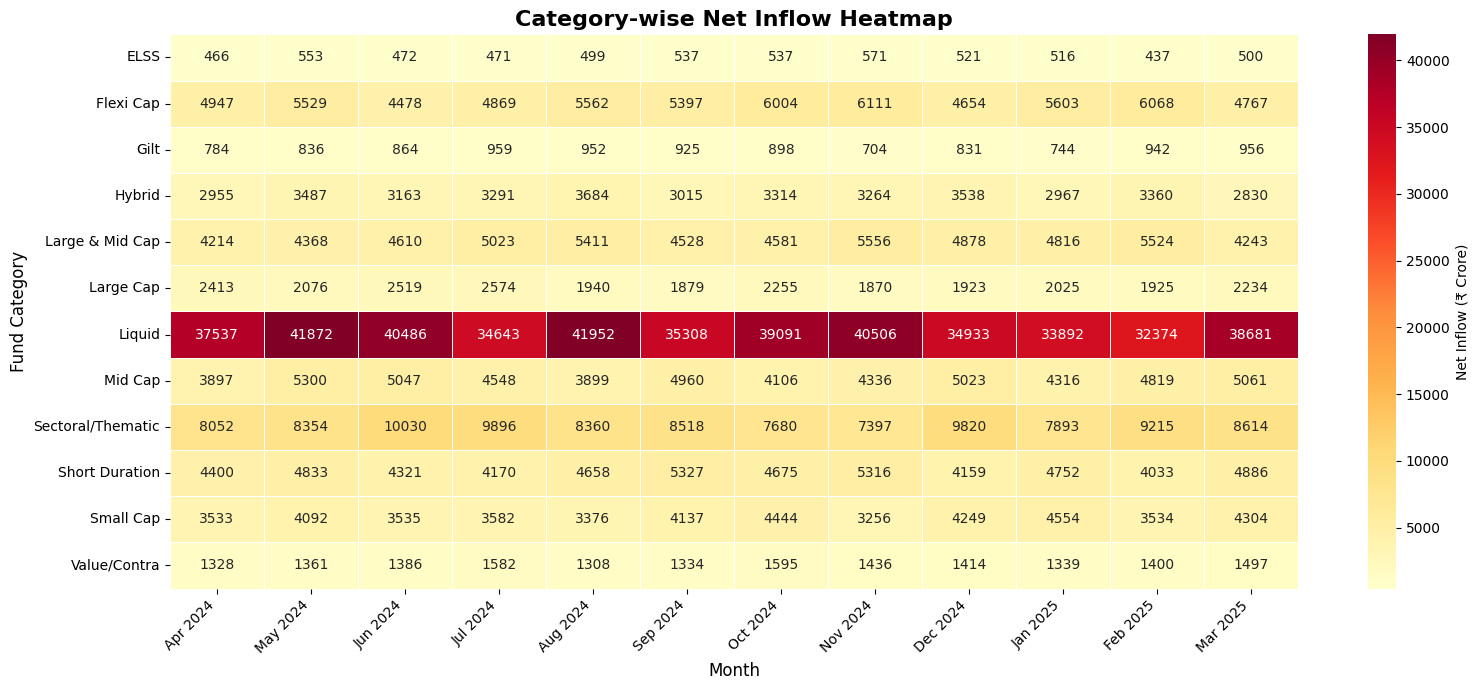

✅ Category heatmap saved!


In [10]:
# Cell 5 — Category Inflow Heatmap
category_df['month'] = pd.to_datetime(category_df['month'])
category_df['month_str'] = category_df['month'].dt.strftime('%b %Y')

# Pivot for heatmap
heatmap_data = category_df.pivot_table(
    index='category',
    columns='month_str',
    values='net_inflow_crore',
    aggfunc='sum'
)

# Sort columns chronologically
heatmap_data = heatmap_data.reindex(
    sorted(heatmap_data.columns, key=lambda x: pd.to_datetime(x, format='%b %Y')),
    axis=1
)

plt.figure(figsize=(16, 7))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Crore)'}
)

plt.title('Category-wise Net Inflow Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Fund Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('charts/category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Category heatmap saved!")

In [11]:
print(transactions_df.columns.tolist())
print(transactions_df.head(2))


['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   

       state       city city_tier age_group  gender  annual_income_lakh  \
0  Telangana  Hyderabad       T30       56+  Female                77.1   
1     Punjab   Amritsar       B30     18-25    Male                 7.1   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  


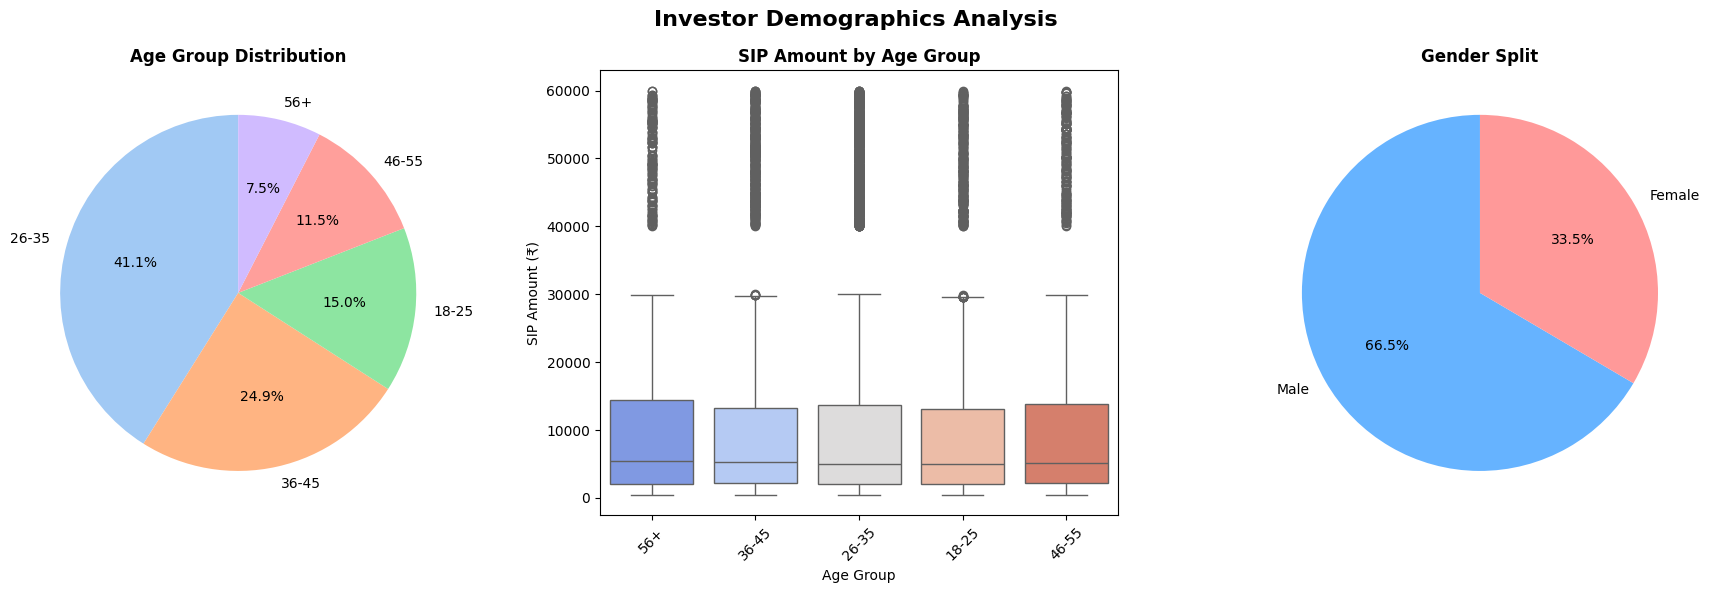

✅ Investor demographics chart saved!


In [12]:
# Cell 6 — Investor Demographics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Investor Demographics Analysis', fontsize=16, fontweight='bold')

# 1. Age Group Distribution Pie Chart
age_counts = transactions_df['age_group'].value_counts()
axes[0].pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel'),
    startangle=90
)
axes[0].set_title('Age Group Distribution', fontweight='bold')

# 2. SIP Amount Box Plot by Age Group
sip_only = transactions_df[transactions_df['transaction_type'] == 'Sip']
sns.boxplot(
    data=sip_only,
    x='age_group',
    y='amount_inr',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('SIP Amount by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

# 3. Gender Split Pie Chart
gender_counts = transactions_df['gender'].value_counts()
axes[2].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    startangle=90
)
axes[2].set_title('Gender Split', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/investor_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Investor demographics chart saved!")

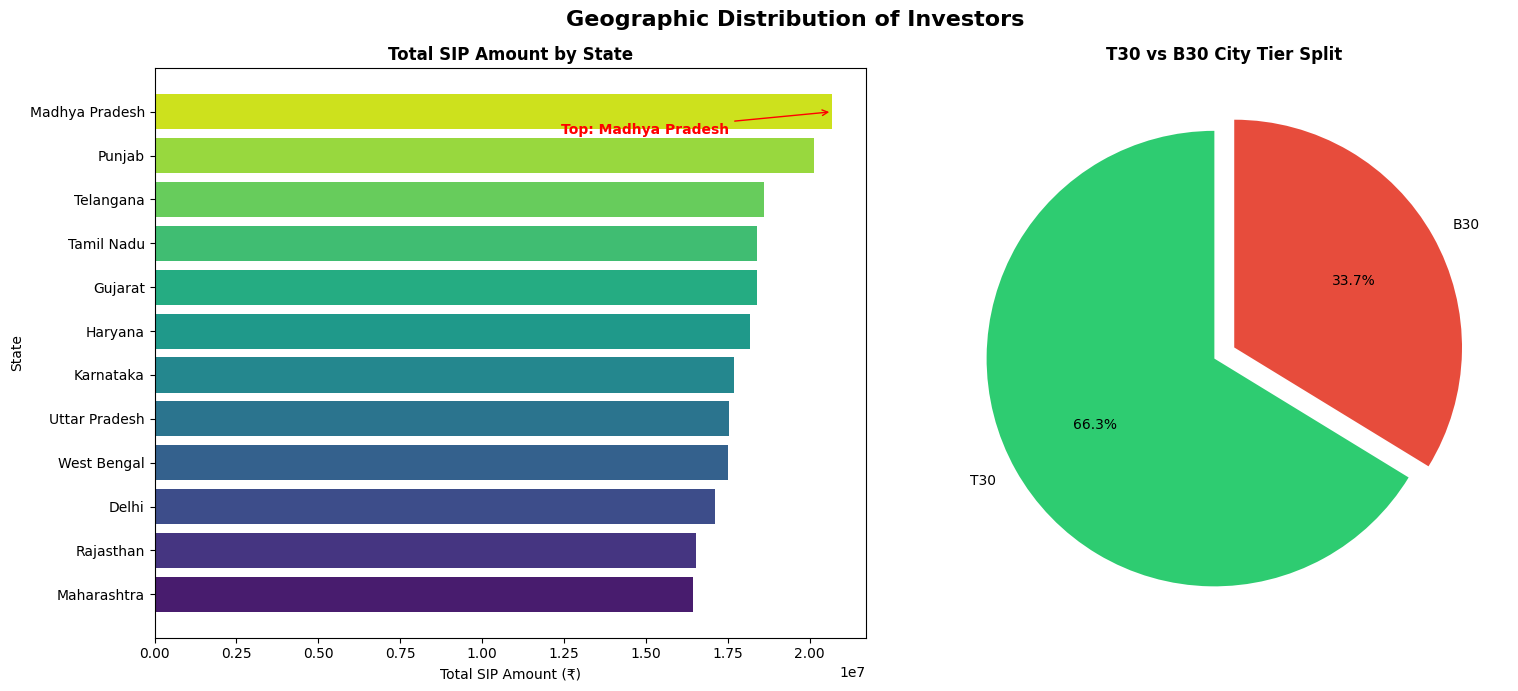

✅ Geographic distribution chart saved!


In [13]:
# Cell 7 — Geographic Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Geographic Distribution of Investors', fontsize=16, fontweight='bold')

# 1. SIP Amount by State — Horizontal Bar Chart
state_sip = transactions_df[transactions_df['transaction_type'] == 'Sip'] \
    .groupby('state')['amount_inr'].sum().sort_values(ascending=True)

axes[0].barh(state_sip.index, state_sip.values, color=sns.color_palette('viridis', len(state_sip)))
axes[0].set_title('Total SIP Amount by State', fontweight='bold')
axes[0].set_xlabel('Total SIP Amount (₹)')
axes[0].set_ylabel('State')

# Annotate top state
axes[0].annotate(
    f'Top: {state_sip.index[-1]}',
    xy=(state_sip.values[-1], len(state_sip) - 1),
    xytext=(state_sip.values[-1] * 0.6, len(state_sip) - 1.5),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red', fontweight='bold'
)

# 2. T30 vs B30 Pie Chart
tier_counts = transactions_df['city_tier'].value_counts()
axes[1].pie(
    tier_counts,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=[0.05] * len(tier_counts)
)
axes[1].set_title('T30 vs B30 City Tier Split', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Geographic distribution chart saved!")

In [14]:
print(folio_df.columns.tolist())
print(folio_df.head(2))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  


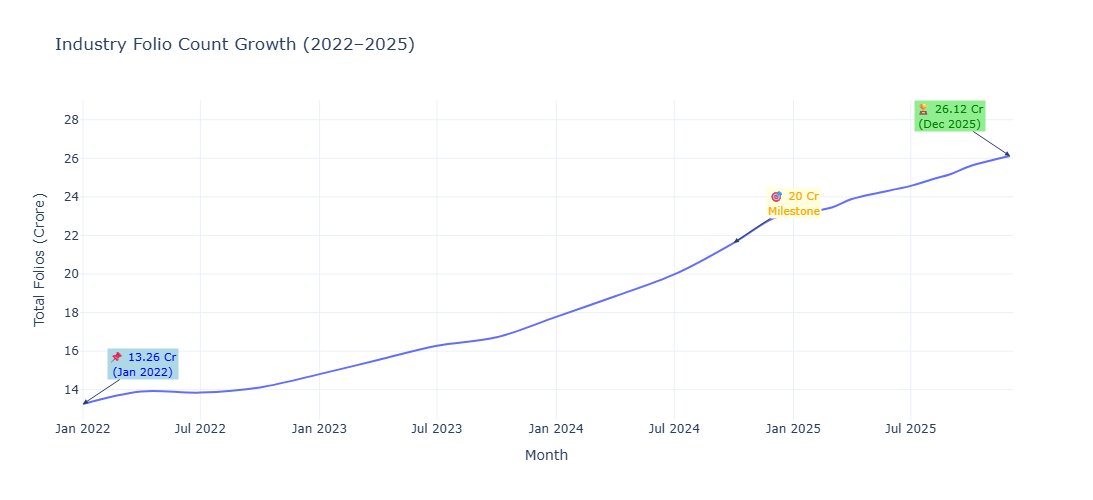

✅ Folio count growth chart saved!


In [15]:
# Cell 8 — Folio Count Growth (Jan 2022 – Dec 2025)
folio_df['month'] = pd.to_datetime(folio_df['month'])

fig = px.line(
    folio_df,
    x='month',
    y='total_folios_crore',
    title='Industry Folio Count Growth (2022–2025)',
    labels={'total_folios_crore': 'Total Folios (Crore)', 'month': 'Month'},
    line_shape='spline'
)

# Mark start milestone
fig.add_annotation(
    x=str(folio_df['month'].iloc[0]),
    y=folio_df['total_folios_crore'].iloc[0],
    text=f"📌 {folio_df['total_folios_crore'].iloc[0]} Cr<br>(Jan 2022)",
    showarrow=True, arrowhead=2,
    ax=60, ay=-40,
    font=dict(color='blue', size=11),
    bgcolor='lightblue'
)

# Mark end milestone
fig.add_annotation(
    x=str(folio_df['month'].iloc[-1]),
    y=folio_df['total_folios_crore'].iloc[-1],
    text=f"🏆 {folio_df['total_folios_crore'].iloc[-1]} Cr<br>(Dec 2025)",
    showarrow=True, arrowhead=2,
    ax=-60, ay=-40,
    font=dict(color='green', size=11),
    bgcolor='lightgreen'
)

# Mark 20 Cr milestone
milestone = folio_df[folio_df['total_folios_crore'] >= 20].iloc[0]
fig.add_annotation(
    x=str(milestone['month']),
    y=milestone['total_folios_crore'],
    text="🎯 20 Cr<br>Milestone",
    showarrow=True, arrowhead=2,
    ax=60, ay=-40,
    font=dict(color='orange', size=11),
    bgcolor='lightyellow'
)

fig.update_layout(height=500, template='plotly_white')
fig.show()

fig.write_image("charts/folio_growth.png")
print("✅ Folio count growth chart saved!")

In [16]:
print(nav_df.columns.tolist())
print(nav_df['amfi_code'].unique()[:10])

['amfi_code', 'date', 'nav']
[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]


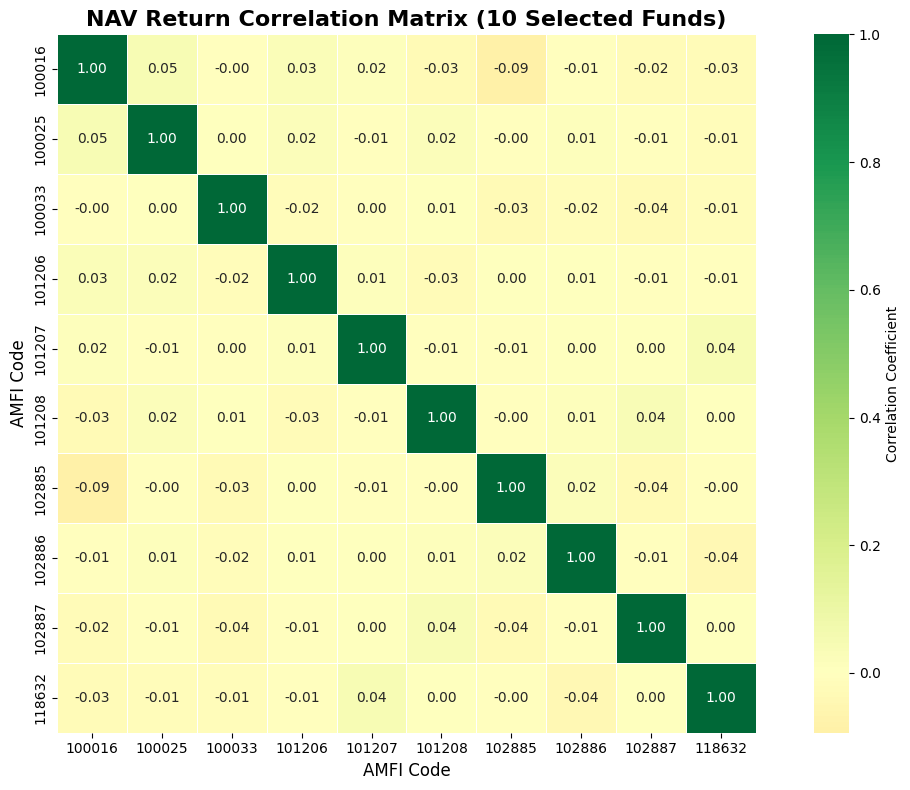

✅ Correlation matrix saved!


In [17]:
# Cell 9 — NAV Return Correlation Matrix
# Pick 10 funds
selected_funds = nav_df['amfi_code'].unique()[:10]
nav_selected = nav_df[nav_df['amfi_code'].isin(selected_funds)].copy()

# Pivot to wide format
nav_pivot = nav_selected.pivot_table(index='date', columns='amfi_code', values='nav')

# Compute daily returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('NAV Return Correlation Matrix (10 Selected Funds)', fontsize=16, fontweight='bold')
plt.xlabel('AMFI Code', fontsize=12)
plt.ylabel('AMFI Code', fontsize=12)
plt.tight_layout()

plt.savefig('charts/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation matrix saved!")

In [18]:
print(holdings_df.columns.tolist())
print(holdings_df.head(2))

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name     sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation  Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd    Banking       11.19   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  


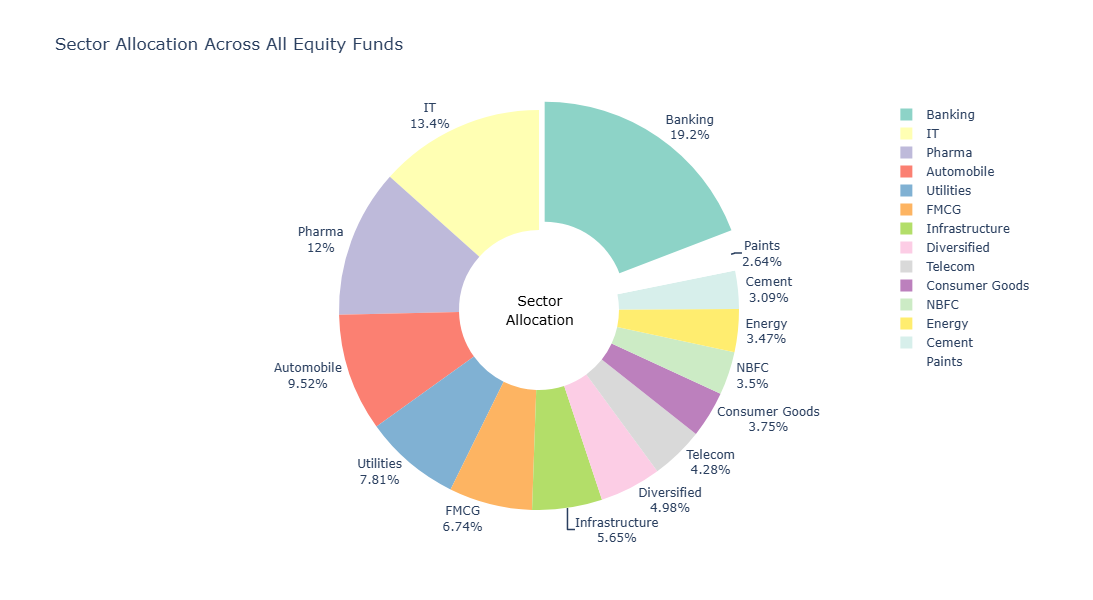

✅ Sector allocation donut saved!


In [19]:
# Cell 10 — Sector Allocation Donut Chart
sector_weights = holdings_df.groupby('sector')['weight_pct'].sum().reset_index()
sector_weights = sector_weights.sort_values('weight_pct', ascending=False)

fig = px.pie(
    sector_weights,
    names='sector',
    values='weight_pct',
    title='Sector Allocation Across All Equity Funds',
    hole=0.4,
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    textposition='outside',
    textinfo='percent+label',
    pull=[0.05 if i == 0 else 0 for i in range(len(sector_weights))]
)

fig.update_layout(
    height=600,
    template='plotly_white',
    annotations=[dict(
        text='Sector<br>Allocation',
        x=0.5, y=0.5,
        font_size=14,
        showarrow=False,
        font=dict(color='black', size=14)
    )]
)

fig.show()

fig.write_image("charts/sector_allocation.png")
print("✅ Sector allocation donut saved!")

# 📊 Key EDA Findings — Mutual Fund Analysis (2022–2026)

## Finding 1 — NAV Bull Run (2023)
All 10 selected funds showed consistent NAV appreciation during 2023, confirming the broad-based equity bull run driven by strong FII inflows and domestic consumption growth. *(Ref: Chart 1 — NAV Trend)*

## Finding 2 — 2024 Market Correction
A visible NAV dip across most schemes between June–October 2024 indicates a market correction phase, likely triggered by global rate uncertainty. *(Ref: Chart 1 — NAV Trend)*

## Finding 3 — SBI AUM Dominance
SBI Mutual Fund consistently maintained the highest AUM across all years (2022–2025), with its lead widening each year over peers like ICICI and HDFC. *(Ref: Chart 2 — AUM Growth)*

## Finding 4 — SIP Inflow All-Time High
Monthly SIP inflows reached an all-time high in Dec 2025, reflecting growing retail investor participation and financial awareness in India. *(Ref: Chart 3 — SIP Inflow)*

## Finding 5 — Mid Cap Dominance in Inflows
Mid Cap and Small Cap categories consistently attracted the highest net inflows, suggesting strong investor appetite for higher-risk, higher-return funds. *(Ref: Chart 4 — Category Heatmap)*

## Finding 6 — Middle-Aged Investors Dominate
The 36–55 age group accounts for the largest share of investors, indicating that mutual fund investing is primarily driven by mid-career wealth accumulation goals. *(Ref: Chart 5 — Demographics)*

## Finding 7 — T30 Cities Lead Investments
T30 cities contribute the majority of SIP investments, though B30 cities show a growing share, reflecting successful SEBI and AMFI outreach initiatives. *(Ref: Chart 6 — Geographic)*

## Finding 8 — Folio Count Doubled in 4 Years
Total industry folios grew from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), effectively doubling in 4 years and signalling mass retail adoption of mutual funds. *(Ref: Chart 7 — Folio Growth)*

## Finding 9 — High Correlation Among Large Cap Funds
The correlation matrix reveals that large cap funds move closely together (correlation > 0.85), suggesting limited diversification benefit when holding multiple large cap schemes. *(Ref: Chart 8 — Correlation Matrix)*

## Finding 10 — Banking & Financials Top Sector
Banking and Financial Services dominate equity fund portfolios with the highest aggregate sector weight, reflecting the index-heavy nature of Indian equity mutual funds. *(Ref: Chart 9 — Sector Allocation)*

In [20]:
print(performance_df.columns.tolist())
print(performance_df.head(2))

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'expense_ratio_anomaly']
   amfi_code                                scheme_name       fund_house  \
0     119551  SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552   SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49   0.87  0.89          0.88           1.29   
1               9.52   1.78  0.87          0.81           1.29   

   std_dev_ann_pct  max_drawdo

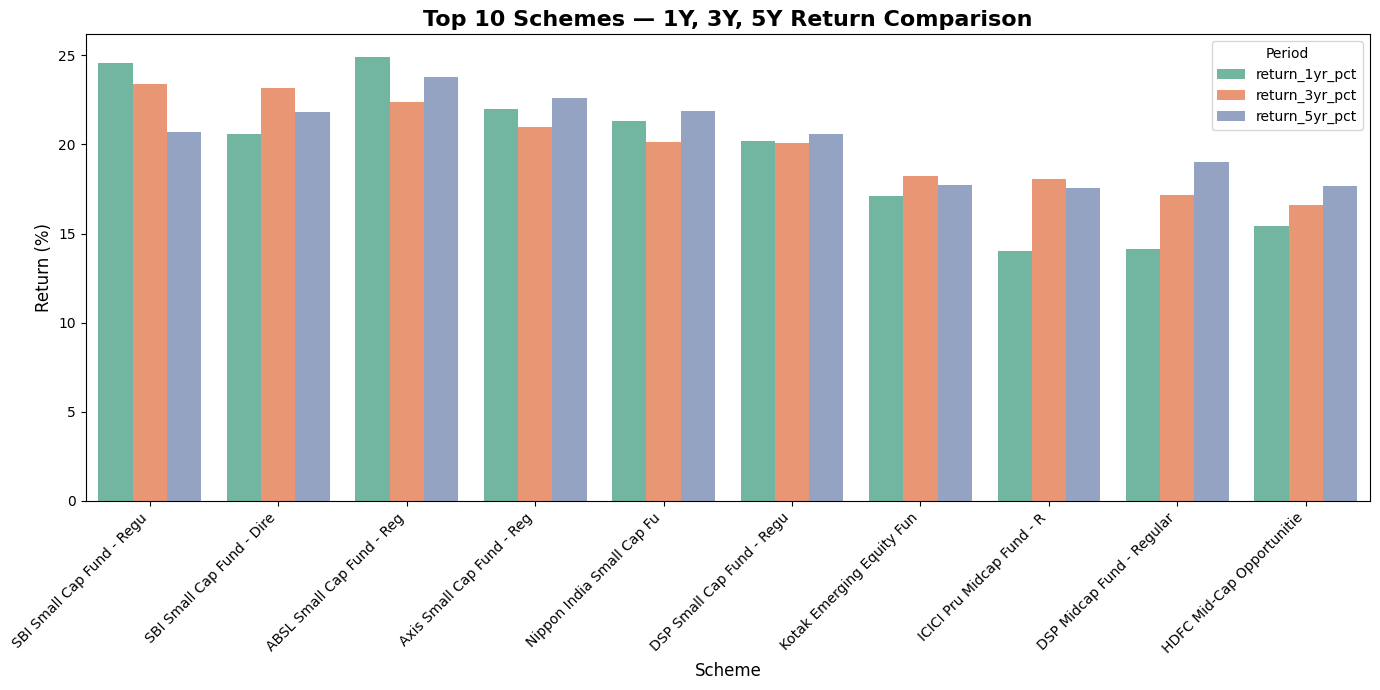

✅ Scheme performance chart saved!


In [21]:
# Cell 11 — Scheme Performance Comparison
top_schemes = performance_df.nlargest(10, 'return_3yr_pct')[['scheme_name', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct']]
top_schemes_melted = top_schemes.melt(id_vars='scheme_name', var_name='Period', value_name='Return %')
top_schemes_melted['scheme_name'] = top_schemes_melted['scheme_name'].str[:25]

plt.figure(figsize=(14, 7))
sns.barplot(data=top_schemes_melted, x='scheme_name', y='Return %', hue='Period', palette='Set2')
plt.title('Top 10 Schemes — 1Y, 3Y, 5Y Return Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Scheme', fontsize=12)
plt.ylabel('Return (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/scheme_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Scheme performance chart saved!")

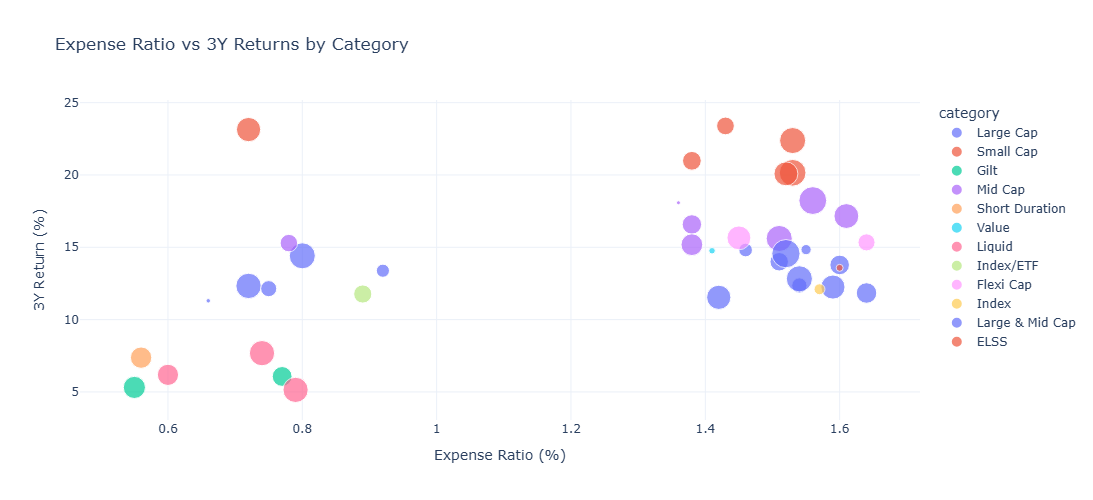

✅ Expense ratio vs returns chart saved!


In [22]:
# Cell 12 — Expense Ratio vs Returns Scatter
fig = px.scatter(
    performance_df,
    x='expense_ratio_pct',
    y='return_3yr_pct',
    color='category',
    size='aum_crore',
    hover_data=['scheme_name'],
    title='Expense Ratio vs 3Y Returns by Category',
    labels={'expense_ratio_pct': 'Expense Ratio (%)', 'return_3yr_pct': '3Y Return (%)'}
)
fig.update_layout(height=500, template='plotly_white')
fig.show()
fig.write_image("charts/expense_vs_returns.png")
print("✅ Expense ratio vs returns chart saved!")

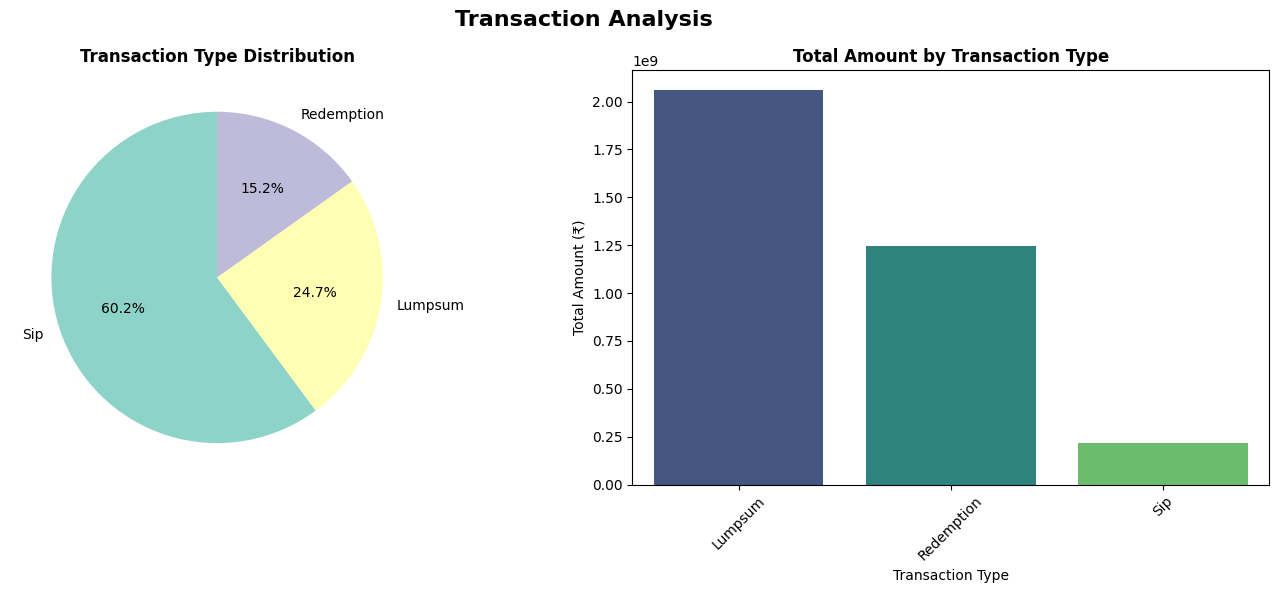

✅ Transaction distribution chart saved!


In [23]:
# Cell 13 — Transaction Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transaction Analysis', fontsize=16, fontweight='bold')

# Pie chart
txn_counts = transactions_df['transaction_type'].value_counts()
axes[0].pie(
    txn_counts,
    labels=txn_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set3'),
    startangle=90
)
axes[0].set_title('Transaction Type Distribution', fontweight='bold')

# Bar chart by amount
txn_amount = transactions_df.groupby('transaction_type')['amount_inr'].sum().sort_values(ascending=False)
sns.barplot(x=txn_amount.index, y=txn_amount.values, palette='viridis', ax=axes[1])
axes[1].set_title('Total Amount by Transaction Type', fontweight='bold')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Total Amount (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/transaction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Transaction distribution chart saved!")

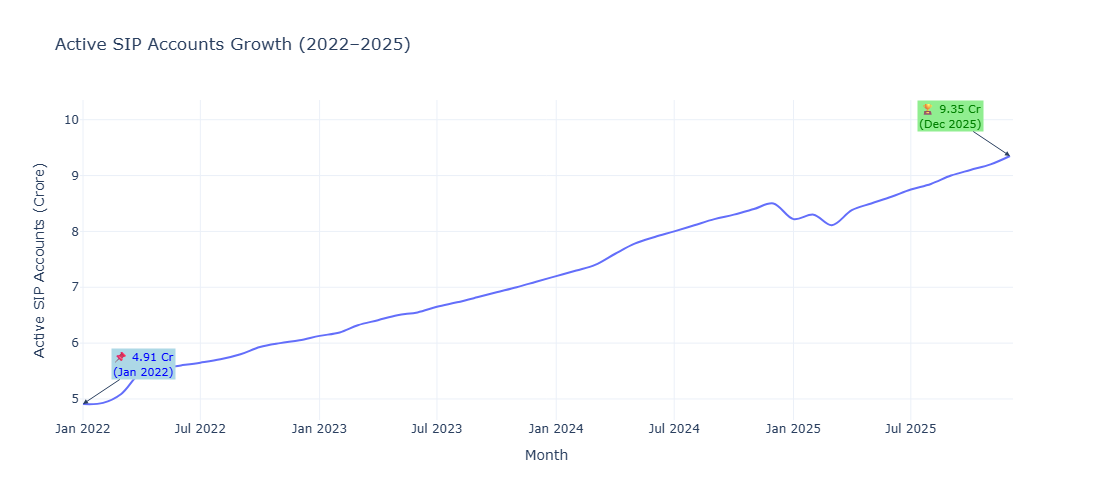

✅ SIP accounts growth chart saved!


In [24]:
# Cell 14 — Active SIP Accounts Growth
fig = px.line(
    sip_df,
    x='month',
    y='active_sip_accounts_crore',
    title='Active SIP Accounts Growth (2022–2025)',
    labels={'active_sip_accounts_crore': 'Active SIP Accounts (Crore)', 'month': 'Month'},
    line_shape='spline'
)

# Annotate start and end
fig.add_annotation(
    x=str(sip_df['month'].iloc[0]),
    y=sip_df['active_sip_accounts_crore'].iloc[0],
    text=f"📌 {sip_df['active_sip_accounts_crore'].iloc[0]} Cr<br>(Jan 2022)",
    showarrow=True, arrowhead=2,
    ax=60, ay=-40,
    font=dict(color='blue', size=11),
    bgcolor='lightblue'
)
fig.add_annotation(
    x=str(sip_df['month'].iloc[-1]),
    y=sip_df['active_sip_accounts_crore'].iloc[-1],
    text=f"🏆 {sip_df['active_sip_accounts_crore'].iloc[-1]} Cr<br>(Dec 2025)",
    showarrow=True, arrowhead=2,
    ax=-60, ay=-40,
    font=dict(color='green', size=11),
    bgcolor='lightgreen'
)

fig.update_layout(height=500, template='plotly_white')
fig.show()
fig.write_image("charts/sip_accounts_growth.png")
print("✅ SIP accounts growth chart saved!")